# Построение таблиц частот в Python

**Дисциплина:** Введение в анализ больших данных

Тема занятия — перевод непрерывных (или порядковых) чисел в **категории**, подсчёт частот и визуализация:
- разбиение на интервалы (`pd.cut`);
- абсолютные и относительные частоты (`value_counts`);
- объединение таблиц (`pd.concat`);
- столбчатые и круговые диаграммы.

Примеры ниже используют **возрасты сотрудников двух отделов** и свои границы интервалов.


## 0. Импорт и демо-данные


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

# Исходные данные
god1 = np.array([83,70,86,51,61,67,80,84,70,64,83,55,88,75,61,70,95,52,75,92,
                 86,89,83,58,51,65,87,54,90,62,67,66,83,65,70,87,69,51,51,60,
                 52,74,80,79,85,85,92,22,92,57,84,92])
god2 = np.array([70,31,70,46,78,69,36,33,65,70,74,51,90,26,62,70,86,86,80,33,
                 55,31,69,31,62,63,86,55,69,62,31,90,31,31,69,64,57,75,53,89,
                 0,31,81,53,86,52,98,58,31,69,69,51,75,39,0,56,51,69,46,41,65])

# Параметры шкал (вынесены для читаемости)
bins_five = [-0.01, 50, 68, 85, 100]
labels_five = ["2", "3", "4", "5"]

bins_euro = [-0.01, 30, 50, 60, 68, 85, 95, 100]
labels_euro = ["F", "FX", "E", "D", "C", "B", "A"]


---
## 1. Разбиение на категории: `pd.cut`

Числовой вектор «нарезается» на интервалы. Нужны:
- **bins** — границы интервалов (или число равных интервалов);
- **labels** — имена категорий;
- **include_lowest=True** — чтобы минимальное значение не стало `NaN`.

**Пример шкалы «возрастные группы»:**

| Группа | Возраст |
|--------|---------|
| junior | 18–29 |
| mid | 30–44 |
| senior | 45–54 |
| lead | 55–70 |


In [3]:
# Задание 1: год1
razb1_1 = pd.cut(god1, bins=bins_five, labels=labels_five, include_lowest=True)
razb1_2 = pd.cut(god1, bins=bins_euro, labels=labels_euro, include_lowest=True)

# Задание 2: год2
razb2_1 = pd.cut(god2, bins=bins_five, labels=labels_five, include_lowest=True)
razb2_2 = pd.cut(god2, bins=bins_euro, labels=labels_euro, include_lowest=True)

print("Год1, 5-балльная:\n", razb1_1.value_counts().sort_index(), sep="")

Год1, 5-балльная:
2     1
3    20
4    19
5    12
Name: count, dtype: int64


---
## 2. Таблицы абсолютных частот

`value_counts()` считает, сколько наблюдений попало в каждую категорию.


In [5]:
# Задание 3: пятибалльная
tab1_1 = razb1_1.value_counts().sort_index()
tab2_1 = razb2_1.value_counts().sort_index()

# Задание 4: европейская
tab1_2 = razb1_2.value_counts().sort_index()
tab2_2 = razb2_2.value_counts().sort_index()

print("Таблица 1_1 (год1, 5-балл):\n", tab1_1, sep="")
print("\nТаблица 2_1 (год2, 5-балл):\n", tab2_1, sep="")


Таблица 1_1 (год1, 5-балл):
2     1
3    20
4    19
5    12
Name: count, dtype: int64

Таблица 2_1 (год2, 5-балл):
2    18
3    18
4    17
5     8
Name: count, dtype: int64


---
## 3. Относительные частоты

Доля категории = частота / объём выборки  
(или `value_counts(normalize=True)`).


In [6]:
rel1_1 = tab1_1 / tab1_1.sum()
rel2_1 = tab2_1 / tab2_1.sum()
rel1_2 = tab1_2 / tab1_2.sum()
rel2_2 = tab2_2 / tab2_2.sum()

print("Относительные частоты (год1, 5-балл):\n", rel1_1.round(3), sep="")


Относительные частоты (год1, 5-балл):
2    0.019
3    0.385
4    0.365
5    0.231
Name: count, dtype: float64


---
## 4. Столбчатые диаграммы по таблицам частот

Несколько графиков в одном окне: `plt.subplots(nrows, ncols)`.


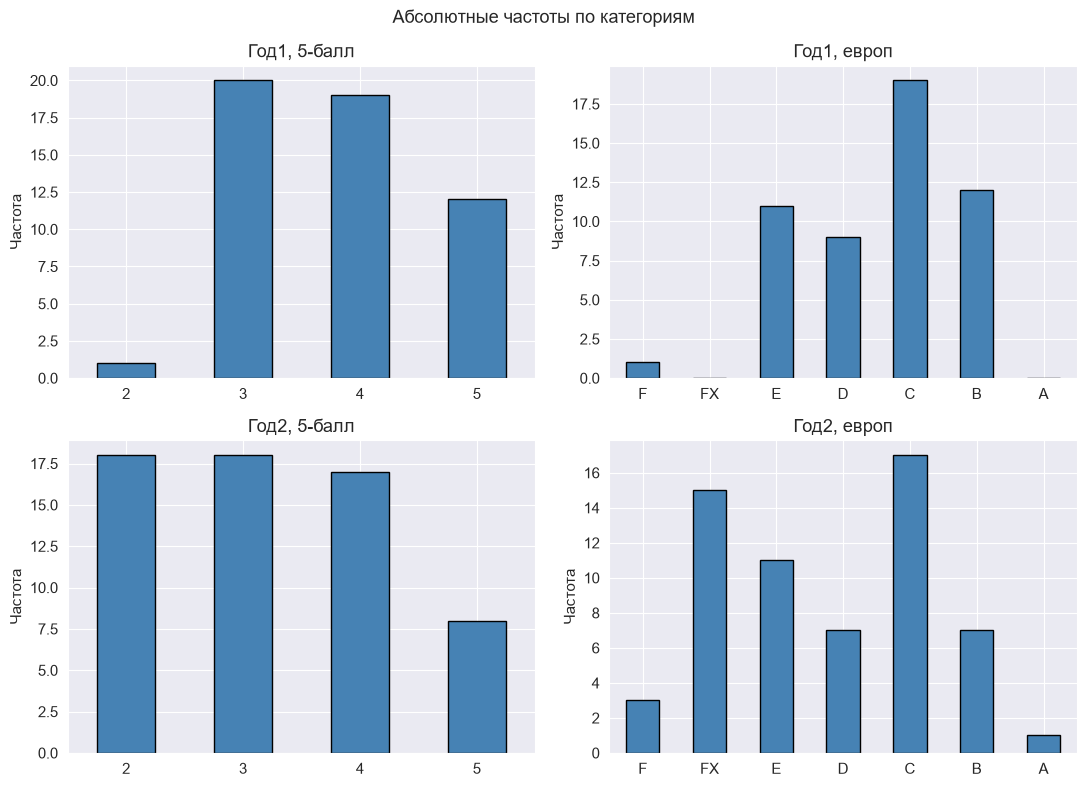

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

freq_A.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Отдел A")
axes[0].set_ylabel("Частота")
axes[0].tick_params(axis="x", rotation=0)

freq_B.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="black")
axes[1].set_title("Отдел B")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Возрастные группы: абсолютные частоты")
plt.tight_layout()
plt.show()


---
## 5. Объединение таблиц: `pd.concat`

Две (и более) серии частот можно сложить в одну таблицу по столбцам или по строкам.


In [10]:
matrix1 = pd.concat([tab1_1, tab2_1], axis=1, keys=["Год1", "Год2"]).fillna(0).astype(int)
matrix2 = pd.concat([tab1_2, tab2_2], axis=1, keys=["Год1", "Год2"]).fillna(0).astype(int)

print("Матрица 1 (5-балльная):\n", matrix1, sep="")


Матрица 1 (5-балльная):
   Год1  Год2
2     1    18
3    20    18
4    19    17
5    12     8


### Stacked и grouped barplot


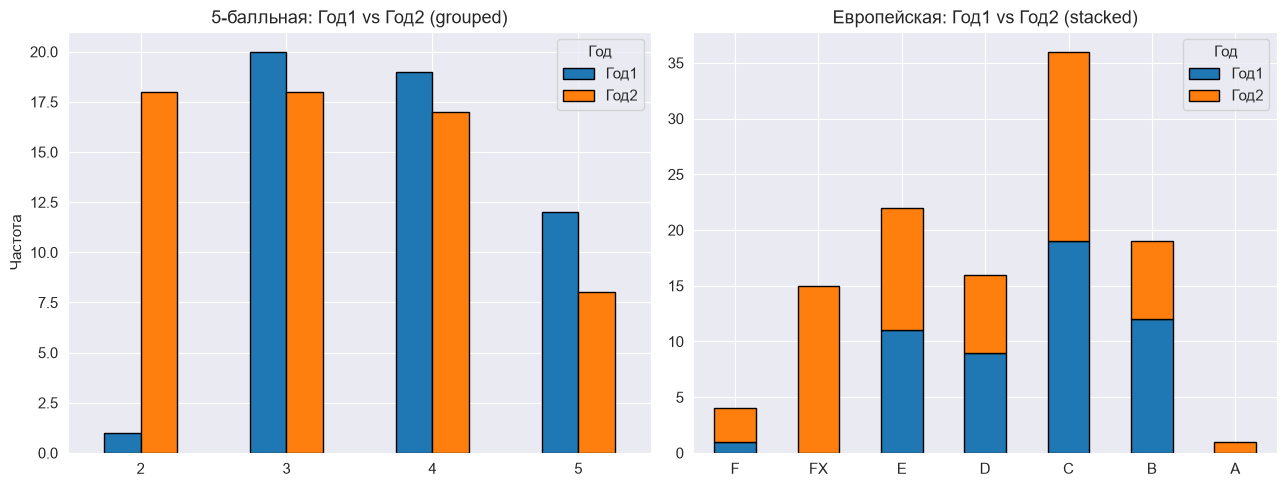

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

matrix1.plot.bar(ax=axes[0], edgecolor="black")
axes[0].set_title("5-балльная: Год1 vs Год2 (grouped)")
axes[0].set_ylabel("Частота")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Год")

matrix2.plot.bar(stacked=True, ax=axes[1], edgecolor="black")
axes[1].set_title("Европейская: Год1 vs Год2 (stacked)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Год")

plt.tight_layout()
plt.show()


---
## 6. Круговые диаграммы

`plt.pie` показывает структуру как доли целого.


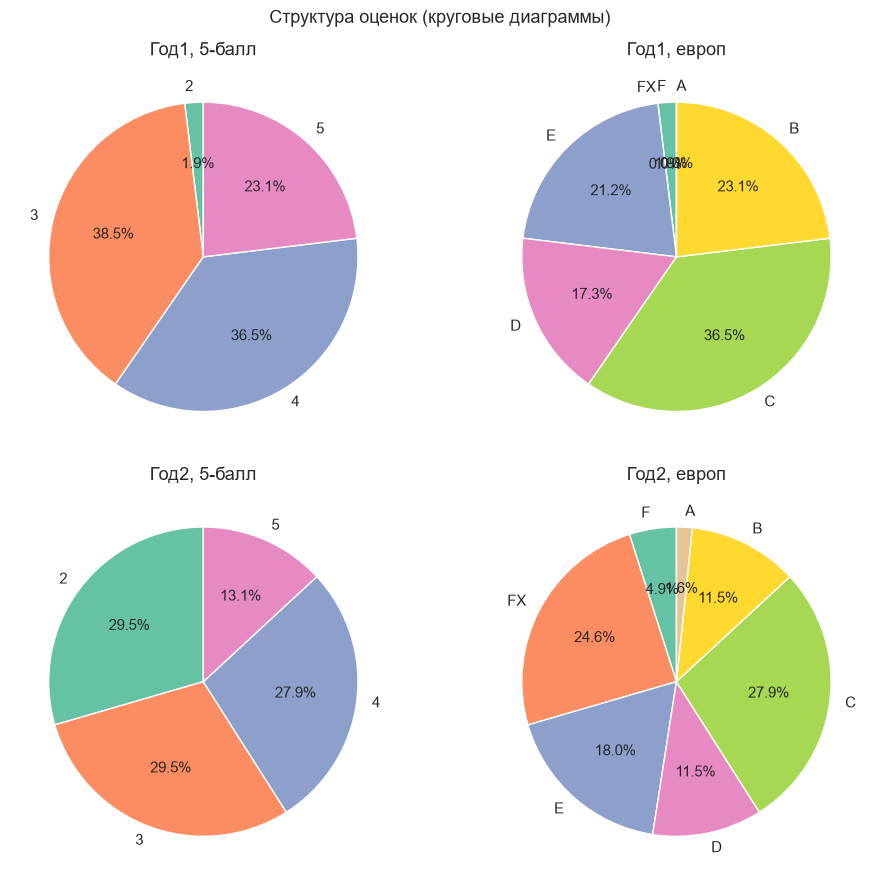

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
colors = plt.cm.Set2.colors

for ax, title, s in zip(axes.ravel(), titles, data):
    ax.pie(s, labels=s.index, autopct="%1.1f%%",
           colors=colors[:len(s)], startangle=90)
    ax.set_title(title)

plt.suptitle("Структура оценок (круговые диаграммы)")
plt.tight_layout()
plt.show()


---
## Шпаргалка по методам (Python)

| Задача | Код |
|--------|-----|
| Разбить на интервалы | `pd.cut(x, bins=..., labels=..., include_lowest=True)` |
| Абсолютные частоты | `series.value_counts()` |
| Относительные частоты | `series.value_counts(normalize=True)` или `counts / n` |
| Склеить столбцы | `pd.concat([a, b], axis=1)` |
| Склеить строки | `pd.concat([a, b], axis=0)` |
| Столбчатая диаграмма | `series.plot(kind="bar")` |
| Stacked / grouped | `df.plot(kind="bar", stacked=True/False)` |
| Круговая | `plt.pie(values, labels=..., autopct="%1.1f%%")` |
| Несколько графиков | `plt.subplots(nrows, ncols)` |

